In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits import axisartist
import numpy as np

from ep_processing import *
from utils.visualization import * 

# Plotting stuff
TITLE_FONT_SIZE = 20
TICK_FONT_SIZE = 21
XAXIS_TITLE_FONT_SIZE = 24

plt.rc('axes', labelsize = TITLE_FONT_SIZE)
plt.rc('xtick', labelsize = TICK_FONT_SIZE, direction = "out") 
plt.rc('ytick', labelsize = TICK_FONT_SIZE, direction = "out")

default_markersize = 40
default_minor_markersize = 12
default_linewidth = 4

In [6]:
#base_dir = "sm04-data/tropical/"
base_dir = "sm04-data/midlatitude/"

avgpr_convective_alpha = np.loadtxt(base_dir + "sm04-alpha-avg-param.txt")
avgpr_resolved_alpha = np.loadtxt(base_dir + "sm04-alpha-avg-resolved.txt")
avgpr_total_alpha = np.loadtxt(base_dir + "sm04-alpha-avg-total.txt")
ax00_content = np.stack([avgpr_convective_alpha, avgpr_resolved_alpha, avgpr_total_alpha])

pr_convective_alpha = np.loadtxt(base_dir + "sm04-alpha-epe-param.txt")
pr_resolved_alpha = np.loadtxt(base_dir + "sm04-alpha-epe-resolved.txt")
pr_total_alpha = np.loadtxt(base_dir + "sm04-alpha-epe-total.txt")
ax01_content = np.stack([pr_convective_alpha, pr_resolved_alpha, pr_total_alpha])

avgpr_convective_taud = np.loadtxt(base_dir + "sm04-taud-avg-param.txt")
avgpr_resolved_taud = np.loadtxt(base_dir + "sm04-taud-avg-resolved.txt")
avgpr_total_taud = np.loadtxt(base_dir + "sm04-taud-avg-total.txt")
ax10_content = np.stack([avgpr_convective_taud, avgpr_resolved_taud, avgpr_total_taud])

pr_convective_taud = np.loadtxt(base_dir + "sm04-taud-epe-param.txt")
pr_resolved_taud = np.loadtxt(base_dir + "sm04-taud-epe-resolved.txt")
pr_total_taud = np.loadtxt(base_dir + "sm04-taud-epe-total.txt")
ax11_content = np.stack([pr_convective_taud, pr_resolved_taud, pr_total_taud])

ax_contents = [ax00_content, ax01_content, ax10_content, ax11_content]

In [7]:
alpha_str = ["2e6", "2e7", "2e8", "5e8", "2e9", "2e10"]
alpha = [float(a_str) for a_str in alpha_str]

taud_str = ["12e2", "8e3", "148e2", "21600", "284e2"]
taud = [float(t_str) for t_str in taud_str]

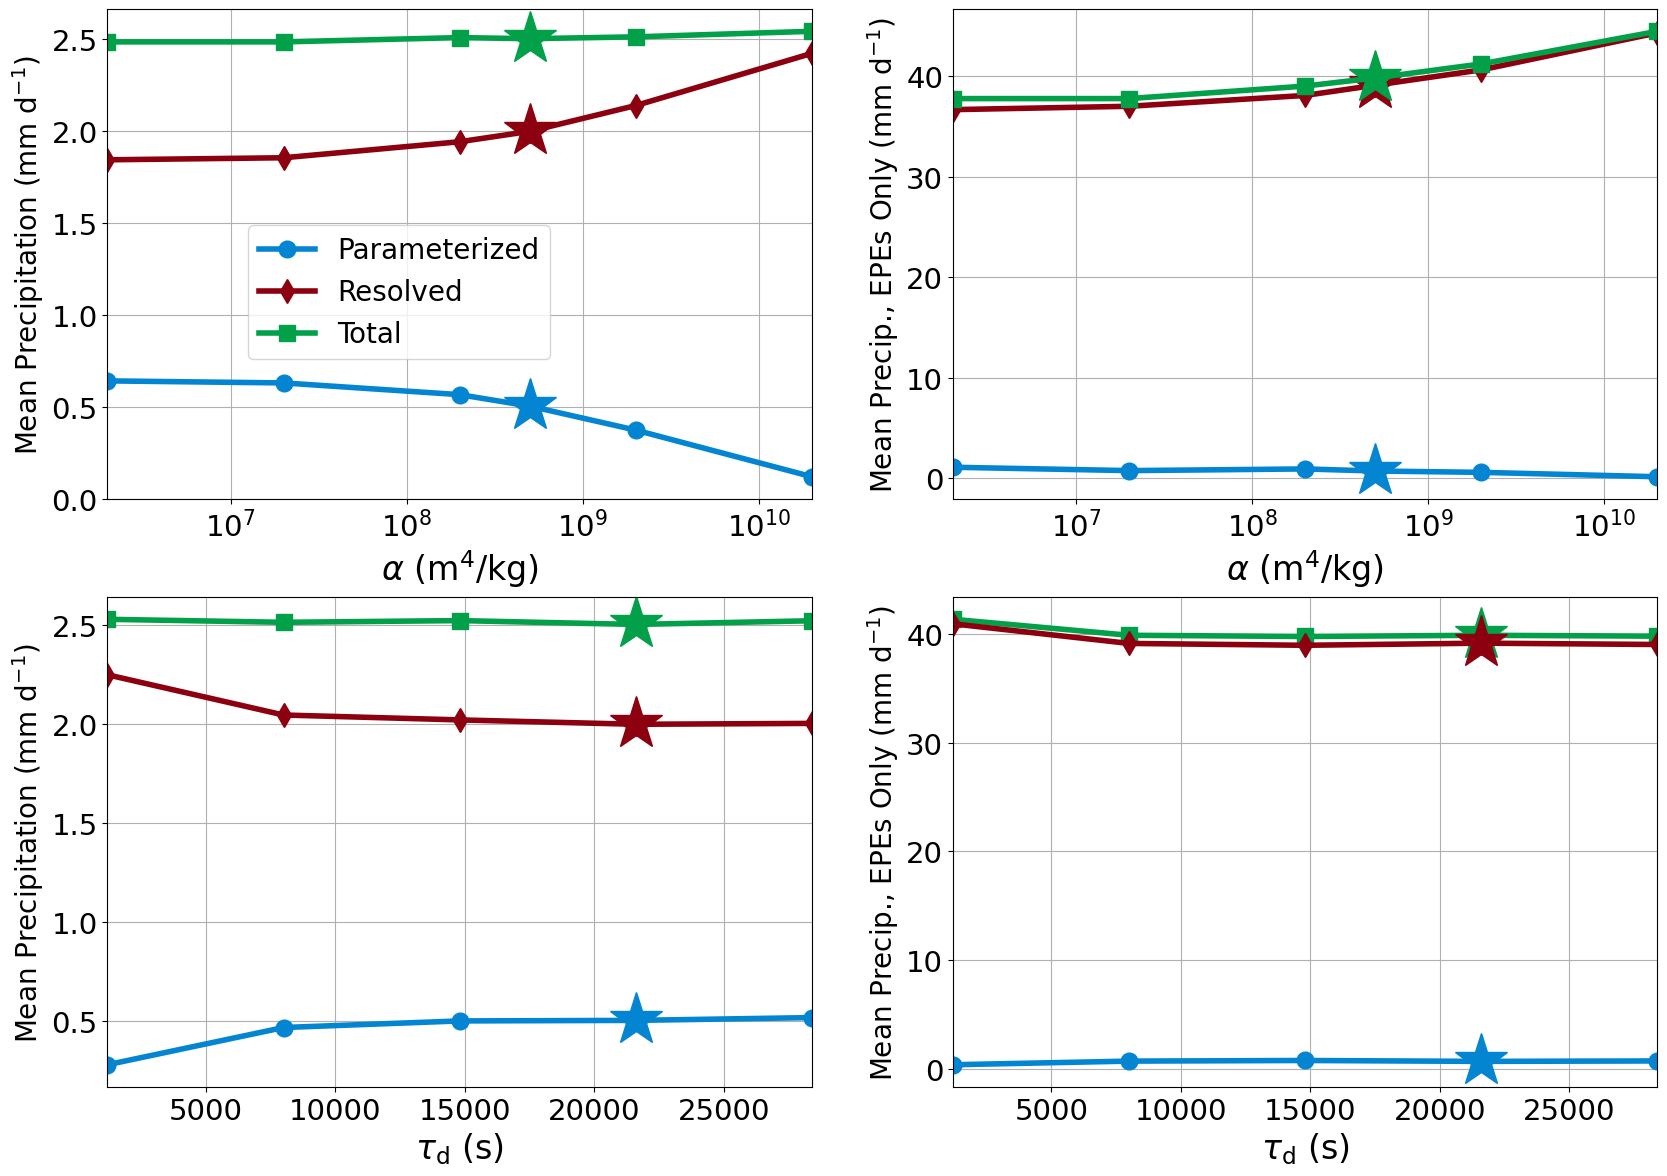

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

row_idx = 0
col_idx = 0

for ax_content in ax_contents:
    ax = axes[row_idx, col_idx]

    ax.grid("on")

    if row_idx == 0:

        ax.semilogx(alpha,
                     ax_content[0],
                     color = "xkcd:cerulean",
                     marker = "o",
                     linestyle = "solid",
                     label = "Parameterized",
                     linewidth = default_linewidth,
                     markersize = default_minor_markersize,
                    )
        
        ax.semilogx(5e8,
                    ax_content[0][3],
                    color = "xkcd:cerulean",
                    marker= "*",
                    markersize =  default_markersize,
                   )
        
        ax.semilogx(alpha,
                     ax_content[1],
                     color = "xkcd:crimson",
                     marker = "d",
                     linestyle = "solid",
                     label = "Resolved",
                     linewidth = default_linewidth,
                     markersize = default_minor_markersize,
                    )
        
        ax.semilogx(5e8,
                    ax_content[1][3],
                    color = "xkcd:crimson",
                    marker= "*",
                    markersize =  default_markersize,
                   )
    
        ax.semilogx(alpha,
                     ax_content[2],
                     color = "xkcd:emerald",
                     marker = "s",
                     linestyle = "solid",
                     label= "Total",
                     linewidth = default_linewidth,
                     markersize = default_minor_markersize,
                    )
    
        ax.semilogx(5e8,
                    ax_content[2][3],
                    color = "xkcd:emerald",
                    marker= "*",
                    markersize =  default_markersize,
                    )

        ax.set_xlim(left = min(alpha), right = max(alpha))
        ax.set_xlabel(r"$\alpha$ ($\mathrm{m}^4$/kg)", fontsize = XAXIS_TITLE_FONT_SIZE)
        # plt.xlim(0.1*alpha[0], 100.*alpha[-1])

        if col_idx == 0:
            
            ax.set_ylabel(r"Mean Precipitation (mm $\mathrm{d}^{-1}$)", fontsize = TITLE_FONT_SIZE)
            #ax.legend(fontsize = TITLE_FONT_SIZE, loc = (0.2, 0.6)) # tropical 
            ax.legend(fontsize = TITLE_FONT_SIZE, loc = (0.2, 0.285)) # midlat
            #ax.set_ylim(1.5, 5.25) # tropical

        if col_idx == 1:
            
            ax.set_ylabel(r"Mean Precip., EPEs Only (mm $\mathrm{d}^{-1}$)", fontsize = TITLE_FONT_SIZE)
            #ax.set_ylim(0, 118) # midlat

    if row_idx == 1:
        
        ax.plot(
            taud, 
            ax_content[2], 
            color = "xkcd:emerald",
            marker = "s",
            linestyle = "solid",
            label= "Total",
            linewidth = default_linewidth,
            markersize = default_minor_markersize,
        )

        ax.plot(21600,
            ax_content[2][3],
            color = "xkcd:emerald",
            marker= "*",
            markersize =  default_markersize,
        )

        ax.plot(taud,
         ax_content[0],
         color = "xkcd:cerulean",
         marker = "o",
         linestyle = "solid",
         label = "Parameterized",
         linewidth = default_linewidth,
         markersize = default_minor_markersize,
        )

        ax.plot(21600,
            ax_content[0][3],
            color = "xkcd:cerulean",
            marker= "*",
            markersize =  default_markersize,
            )

        ax.plot(taud,
         ax_content[1],
         color = "xkcd:crimson",
         marker = "d",
         linestyle = "solid",
         label = "Resolved",
         linewidth = default_linewidth,
         markersize = default_minor_markersize,
        )

        ax.plot(21600,
           ax_content[1][3],
            color = "xkcd:crimson",
            marker= "*",
            markersize =  default_markersize,
            )

        ax.set_xlabel(r"$\tau_{\mathrm{d}}$ (s)", fontsize = XAXIS_TITLE_FONT_SIZE)
        ax.set_xlim(min(taud), max(taud))

        if col_idx == 0:
            
            ax.set_ylabel(r"Mean Precipitation (mm $\mathrm{d}^{-1}$)", fontsize = TITLE_FONT_SIZE)
            #ax.set_ylim(1.75, 5.25) # tropical values

        if col_idx == 1:

            ax.set_ylabel(r"Mean Precip., EPEs Only (mm $\mathrm{d}^{-1}$)", fontsize = TITLE_FONT_SIZE)
            #ax.set_ylim(0,84) # tropical values
        
    ax.minorticks_off()

    if col_idx == 1:
        row_idx = 1
    
    col_idx += 1
    col_idx = col_idx % 2
    
# Save output
#outfile_path = "images/" + "sm04-gallery-tropical" + ".png"
outfile_path = "images/" + "sm04-gallery-midlatitude" + ".png"
plt.savefig(outfile_path, dpi=600, bbox_inches='tight')

#plt.tight_layout()

plt.show()